In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Point, LineString
import os


In [2]:
print(os.listdir('../../data/mydata'))
print(os.listdir('../../data/mydata/network_porto'))

['network_porto', 'osm_feature_0.002', 'osm_feature_0.002.zip', 'osm_feature_0.002_224', 'osm_feature_0.002_224.zip', 'osm_feature_0.002_v2.zip', 'osm_feature_0.01', 'osm_feature_0.01.zip', 'patches', 'patches_0.002', 'patches_0.002_224', 'patches_0.002_224.zip', 'patches_0.003_224', 'patches_0.005', 'patches_0.005_112', 'patches_0.01_112', 'patches_0.01_224', 'patches_0.01_224_v1', 'patches_112x112', 'patches_feat_0.002', 'patches_feat_0.002_224', 'patches_feat_0.002_224.zip', 'patches_feat_0.005_224', 'poi_cell', 'poi_region', 'porto_data.zip', 'porto_edge_index.pt', 'test.npy', 'train.npy', 'val.npy']
['porto_edges.cpg', 'porto_edges.dbf', 'porto_edges.prj', 'porto_edges.shp', 'porto_edges.shx', 'porto_edges_new_simplify.pkl', 'porto_edges_poi_new_simplify.pkl', 'porto_gps.csv', 'porto_nodes.cpg', 'porto_nodes.dbf', 'porto_nodes.prj', 'porto_nodes.shp', 'porto_nodes.shx', 'porto_nodes_new.pkl', 'porto_osmnx.png']


In [3]:
import pickle
data_path = "../../data/mydata/"
with open(os.path.join(data_path,"network_porto/porto_edges_new_simplify.pkl"), 'rb') as f:
    edgeinfo = pickle.load(f)
with open(os.path.join(data_path,"network_porto/porto_nodes_new.pkl"), 'rb') as f:
    nodeinfo = pickle.load(f)

In [4]:
import osmnx as ox
import networkx as nx

In [5]:
min_lat, min_lon, max_lat, max_lon = float('inf'), float('inf'), float('-inf'), float('-inf')
pad = 0.01  # Add a small padding to ensure we capture all nodes
for _, (lon, lat, _) in nodeinfo.items():
    min_lat = min(min_lat, lat)
    max_lat = max(max_lat, lat)
    min_lon = min(min_lon, lon)
    max_lon = max(max_lon, lon)

print(f"Bounding box: ({min_lat}, {min_lon}), ({max_lat}, {max_lon})")

bbox = (min_lon - pad, min_lat - pad, max_lon + pad, max_lat + pad)

Bounding box: (41.1406333, -8.6886988), (41.1858412, -8.5559061)


In [6]:

ox.settings.overpass_settings = f'[out:json][timeout:60][date:"2025-06-20T00:00:00Z"]'


In [7]:
our_nodes = gpd.read_file(os.path.join(data_path,"network_porto/porto_nodes.shp"))
our_edges = gpd.read_file(os.path.join(data_path,"network_porto/porto_edges.shp"))

In [8]:
POI_MAPPING = {
    "restaurant" : "catering", # amenity
    "cafe" : "catering", # amenity
    "fast_food" : "catering", # amenity
    "pub" : "catering", # amenity
    "bar" : "catering", # amenity
    "biergarten" : "catering", # amenity
    
    "school" : "education", # amenity
    "college" : "education", # amenity
    "kindergarten" : "education", # amenity
    "university" : "education", # amenity

    "hospital" : "medical", # amenity

    "bus_station" : "transport", # amenity
    "taxi" : "transport", # amenity
    "bus_stop" : "transport", # highway
    
    
    "parking" : "parking", # parking
    
    "shopping_centre" : "retail", # shop
    "mall" : "retail", # shop

    "supermarket" : "retail", # shop
    "convenience" : "retail", # shop
    
    "hairdresser" : "living", # shop
    "laundry" : "living", # shop
    "beauty" : "living", # shop
    
    "office" : "business", # office
    "industrial" : "business", # landuse
}

In [9]:
tags = {
    "amenity": [
        # catering
        "restaurant", "cafe", "fast_food", "pub", "bar", "biergarten",

        # education
        "school", "college", "kindergarten", "university",

    #     # medical
        "hospital",

    #     # transport
        "bus_station", "taxi",

    ],
    
    "shop": [
        "supermarket", "convenience",
        "hairdresser", "laundry", "beauty",
        "shopping_centre", "mall",
    ],

    "highway": [
        "bus_stop",
    ],

    "office": True,

    "landuse": [
        "industrial",
    ],
    'parking': True
}

gdf_tags = {}

for tag, value in tags.items():
    try:
        gdf_tag = ox.features_from_bbox(bbox=bbox, tags={tag: value})
        gdf_tags[tag] = gdf_tag
    except Exception as e:
        print(f"{tag} failed:", e)
        
gdf_pois = pd.concat(gdf_tags.values())

In [10]:
print(gdf_pois.index.names)

['element', 'id']


In [11]:
gdf_pois = gdf_pois.reset_index()

In [12]:
gdf_pois.head()

,element,id,geometry,amenity,name,website,addr:city,addr:housenumber,addr:postcode,addr:street,...,fee:conditional,motorcycle:parking,markings,parking:both:orientation,maxspeed,parking:lane,parking:lane:left,private,duration,operator:official_name
0,node,90378715,POINT (-8.62811 41.15728),taxi,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,node,112664315,POINT (-8.58248 41.18065),taxi,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,node,416885399,POINT (-8.59226 41.16077),restaurant,Scala,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,node,417992583,POINT (-8.59177 41.16082),restaurant,Vitória,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,node,418091554,POINT (-8.59751 41.15905),restaurant,Barrigas,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [13]:
gdf_pois_reduced = gdf_pois[gdf_pois.geometry.notnull()]
gdf_pois_reduced = gdf_pois_reduced.set_crs(epsg=4326, allow_override=True)

cols = ["element","id","geometry","amenity","shop","highway","office","landuse"]
gdf_pois_reduced = gdf_pois_reduced[[c for c in cols if c in gdf_pois_reduced.columns]]
print(gdf_pois_reduced[cols].notna().sum())

element     7965
id          7965
geometry    7965
amenity     4589
shop         718
highway     1889
office       681
landuse      141
dtype: int64


In [14]:
gdf_pois_reduced['poi_type'] = (
    gdf_pois_reduced['amenity']
    .fillna(gdf_pois_reduced['shop'])
    .fillna(gdf_pois_reduced['highway'])
    .fillna(gdf_pois_reduced['office'])
    .fillna(gdf_pois_reduced['landuse'])
)

gdf_pois_reduced.head()

,element,id,geometry,amenity,shop,highway,office,landuse,poi_type
0,node,90378715,POINT (-8.62811 41.15728),taxi,NaN,NaN,NaN,NaN,taxi
1,node,112664315,POINT (-8.58248 41.18065),taxi,NaN,NaN,NaN,NaN,taxi
2,node,416885399,POINT (-8.59226 41.16077),restaurant,NaN,NaN,NaN,NaN,restaurant
3,node,417992583,POINT (-8.59177 41.16082),restaurant,NaN,NaN,NaN,NaN,restaurant
4,node,418091554,POINT (-8.59751 41.15905),restaurant,NaN,NaN,NaN,NaN,restaurant


In [15]:
gdf_pois_reduced.drop(columns=["amenity","shop","highway","office","landuse"], inplace=True)

print(gdf_pois_reduced['poi_type'].isnull().sum())

6


In [16]:
gdf_pois_reduced.to_file("gdf_pois_filtered.gpkg", layer="pois", driver="GPKG")

In [17]:
print(gdf_pois.element.unique())

['node' 'relation' 'way']


In [18]:
gdf_pois_reduced["poi_group"] = gdf_pois_reduced["poi_type"].map(POI_MAPPING)
gdf_pois_reduced["poi_group"]= gdf_pois_reduced["poi_group"].fillna("other")
gdf_pois_reduced.head()
gdf_pois_reduced["poi_group"].value_counts()

poi_group
catering     2348
transport    1943
parking      1553
other         865
education     413
living        412
retail        285
business      125
medical        21
Name: count, dtype: int64

In [19]:
gdf_pois_reduced.to_file("gdf_pois_grouping.gpkg", layer="pois", driver="GPKG")

In [20]:
gdf_pois = gpd.read_file("gdf_pois_grouping.gpkg", layer="pois")

In [21]:
gdf_edges = our_edges.to_crs(epsg=4326)
gdf_pois = gdf_pois.to_crs(epsg=4326)

In [22]:
minx, miny, maxx, maxy = gdf_pois.total_bounds
print(minx, miny, maxx, maxy)

-8.7030531 41.1299638 -8.5430482 41.203562


In [23]:
gdf_pois = gdf_pois.cx[minx:maxx, miny:maxy]

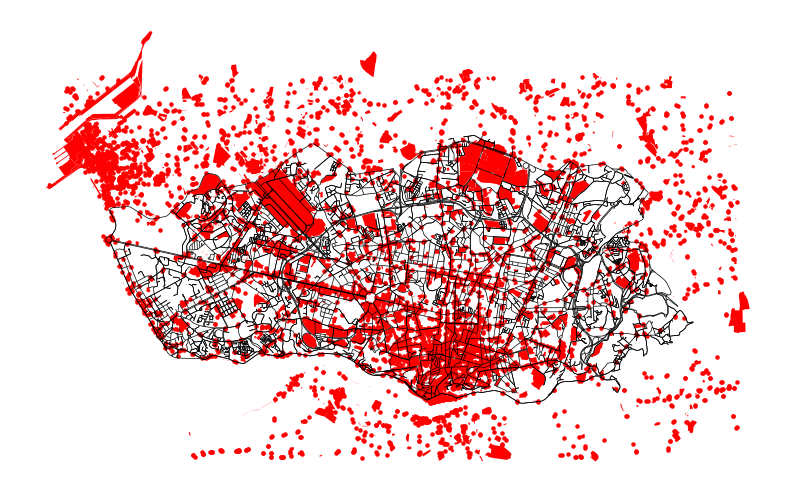

In [24]:
import matplotlib.pyplot as plt

fig, ax =plt.subplots(figsize=(10,10))

gdf_edges.plot(ax=ax, linewidth=0.5, color="black")
gdf_pois.plot(ax=ax, color="red", markersize=5)
ax.axis("off")
plt.show()

In [25]:
gdf_pois = gdf_pois.to_crs(epsg=32648)
gdf_edges = gdf_edges.to_crs(epsg=32648)

In [26]:


BUFFER_METERS = 50

edge_buffered = gdf_edges.copy()

edge_buffered['geometry'] = edge_buffered.geometry.buffer(BUFFER_METERS)

poi_to_segment = gpd.sjoin(
    gdf_pois,
    edge_buffered[["osmid", "geometry"]],
    how="left",
    predicate="within"
)

poi_to_segment.head()

,element,id,poi_type,poi_group,geometry,index_right,osmid
0,node,90378715,taxi,transport,POINT (-4909740.223 12739120.329),353.0,13854848
0,node,90378715,taxi,transport,POINT (-4909740.223 12739120.329),354.0,608418580
0,node,90378715,taxi,transport,POINT (-4909740.223 12739120.329),7821.0,608418577
1,node,112664315,taxi,transport,POINT (-4909668.988 12732738.149),313.0,743461566
2,node,416885399,restaurant,catering,POINT (-4911585.436 12735362.157),408.0,304690306


In [27]:
print(gdf_pois.poi_group.unique())

['transport' 'catering' 'education' 'medical' 'retail' 'living' 'other'
 'business' 'parking']


In [28]:
poi_count = (
    poi_to_segment
    .groupby("osmid")
    .size()
    .reset_index(name="poi_count")
)

poi_group_pivot = (
    poi_to_segment
    .groupby(["osmid", "poi_group"])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)
poi_group_pivot.columns = ["osmid"] + [
    f"poi_{c}" for c in poi_group_pivot.columns[1:]
]

edge_with_poi = gdf_edges.merge(poi_count, on="osmid", how="left")
edge_with_poi = edge_with_poi.merge(poi_group_pivot, on="osmid", how="left")
edge_with_poi["poi_count"] = edge_with_poi["poi_count"].fillna(0).astype(int)
edge_with_poi.head()

,u,v,key,osmid,highway,lanes,maxspeed,oneway,reversed,length,...,poi_count,poi_business,poi_catering,poi_education,poi_living,poi_medical,poi_other,poi_parking,poi_retail,poi_transport
0,25503936,4722746638,0,479127843,motorway_link,2,70,T,False,32.388459,...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,25503936,281726624,0,"[4256507, 1175924414]",motorway_link,1,40,T,False,223.005067,...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,25503951,1243857957,0,4256513,motorway_link,1,40,T,False,112.268166,...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,25503951,4507024043,0,158906049,motorway_link,1,40,T,False,191.891354,...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,25504027,1243857999,0,"[4256491, 108390772, 479127839]",motorway_link,2,70,T,False,118.915183,...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [29]:
import matplotlib.pyplot as plt


# Basic statistics
print("=== POI Count Statistics ===")
print(edge_with_poi["poi_count"].describe())
print(f"\nSegments with 0 POI  : {(edge_with_poi['poi_count'] == 0).sum()}")
print(f"Segments with 1+ POI : {(edge_with_poi['poi_count'] > 0).sum()}")
print(f"Coverage rate        : {(edge_with_poi['poi_count'] > 0).mean():.1%}")

=== POI Count Statistics ===
count    10614.000000
mean         4.384869
std          8.891257
min          0.000000
25%          0.000000
50%          2.000000
75%          4.000000
max        124.000000
Name: poi_count, dtype: float64

Segments with 0 POI  : 4678
Segments with 1+ POI : 5936
Coverage rate        : 55.9%


In [30]:
final_edge_with_poi = edge_with_poi[['u', 'v', 'key', 'osmid', 'geometry', 'poi_count', 'poi_business', 'poi_catering', 'poi_education', 'poi_living', 'poi_other', 'poi_medical', 'poi_parking', 'poi_retail', 'poi_transport']].copy()

In [31]:
print(final_edge_with_poi.columns.tolist())

['u', 'v', 'key', 'osmid', 'geometry', 'poi_count', 'poi_business', 'poi_catering', 'poi_education', 'poi_living', 'poi_other', 'poi_medical', 'poi_parking', 'poi_retail', 'poi_transport']


In [32]:
sample_edge = iter(edgeinfo.items()).__next__()
print(sample_edge)

(0, ['motorway_link', 32.3884588871153, '25503936', '4722746638'])


In [33]:
poi_lookup = final_edge_with_poi.set_index(["u", "v"])

poi_cols = [
    "poi_count", "poi_business", "poi_catering", "poi_education",
    "poi_living", "poi_medical", "poi_other", "poi_parking",
    "poi_retail", "poi_transport"
]

In [34]:
poi_lookup = poi_lookup.sort_index()

In [35]:
for eid, edge in edgeinfo.items():
    u = int(edge[2])
    v = int(edge[3])

    key = (u, v)
    if key in poi_lookup.index:
        row = poi_lookup.loc[key]
        # Handle duplicate (u,v) pairs — take first match
        if isinstance(row, pd.DataFrame):
            row = row.iloc[0]
        poi_values = row[poi_cols].fillna(0).infer_objects(copy=False).tolist()
    else:
        poi_values = [0] * len(poi_cols)

    edge.extend(poi_values)

C:\Users\atom0\AppData\Local\Temp\ipykernel_16208\1232040921.py:11: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  poi_values = row[poi_cols].fillna(0).infer_objects(copy=False).tolist()
C:\Users\atom0\AppData\Local\Temp\ipykernel_16208\1232040921.py:11: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  poi_values = row[poi_cols].fillna(0).infer_objects(copy=False).tolist()
C:\Users\atom0\AppData\Local\Temp\ipykernel_16208\1232040921.py:11: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future vers

In [36]:
sample_key = next(iter(edgeinfo))
print(edgeinfo[sample_key])
print(f"Edge list length: {len(edgeinfo[sample_key])}")  # should be 14

['motorway_link', 32.3884588871153, '25503936', '4722746638', 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Edge list length: 14


In [37]:
sample = next(iter(edgeinfo.values()))
print("Full edge list  :", sample)
print("Total length    :", len(sample))
print("Elements [4:]   :", sample[4:])
print("Count of [4:]   :", len(sample[4:]))

Full edge list  : ['motorway_link', 32.3884588871153, '25503936', '4722746638', 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Total length    : 14
Elements [4:]   : [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Count of [4:]   : 10


=== POI Statistics across EdgeInfo ===
       poi_count  poi_business  poi_catering  poi_education  poi_living  \
count  10614.000     10614.000     10614.000      10614.000   10614.000   
mean       4.379         0.000         1.337          0.041       0.239   
std        8.878         0.029         3.988          0.390       1.114   
min        0.000         0.000         0.000          0.000       0.000   
25%        0.000         0.000         0.000          0.000       0.000   
50%        2.000         0.000         0.000          0.000       0.000   
75%        4.000         0.000         0.000          0.000       0.000   
max      124.000         2.000        46.000          8.000      20.000   

       poi_medical  poi_parking  poi_other  poi_retail  poi_transport  
count    10614.000    10614.000  10614.000   10614.000      10614.000  
mean         0.001        0.360      0.653       0.171          1.578  
std          0.027        1.999      2.739       0.754          3.622

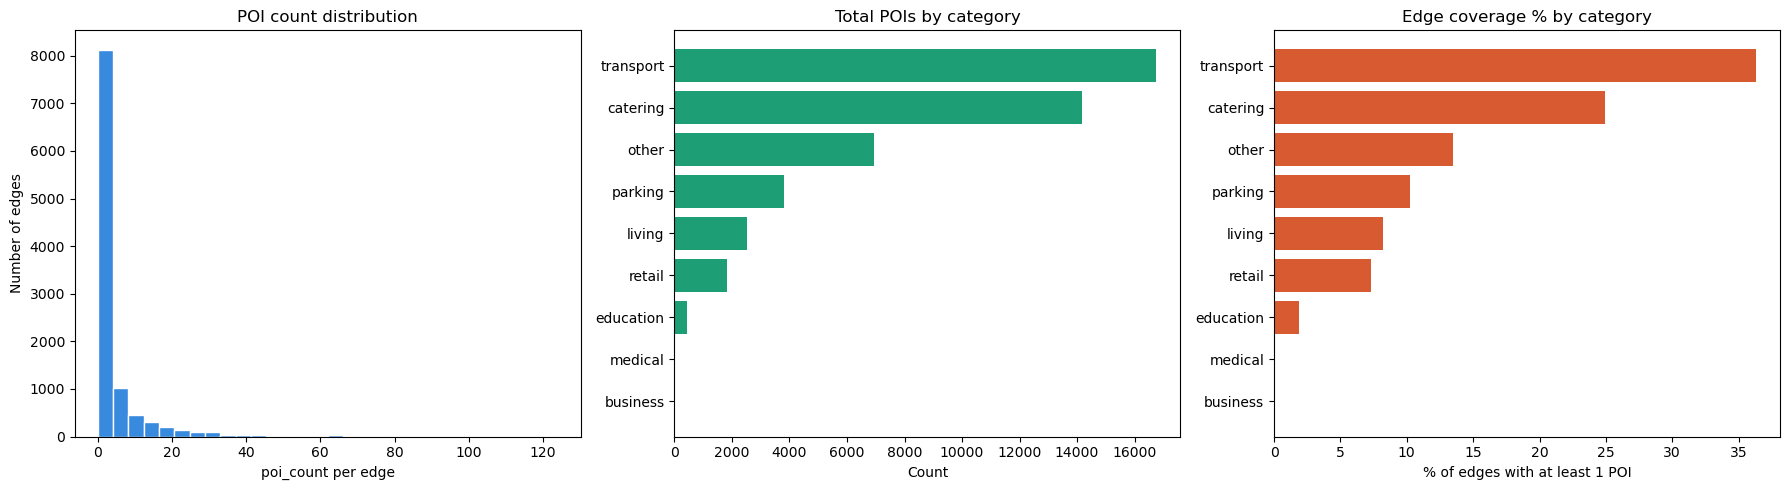

In [38]:
import pandas as pd
import matplotlib.pyplot as plt

poi_cols = [
    "poi_count", "poi_business", "poi_catering", "poi_education",
    "poi_living", "poi_medical", "poi_parking", "poi_other",
    "poi_retail", "poi_transport"
]

# Reconstruct POI values from edgeinfo into a DataFrame
# edge list: [road_type, length, u, v, poi_count, poi_business, ...]
edge_poi_df = pd.DataFrame(
    [edge[4:] for edge in edgeinfo.values()],
    columns=poi_cols
)

# ── 1. Basic statistics ───────────────────────────────────────────
print("=== POI Statistics across EdgeInfo ===")
print(edge_poi_df.describe().round(3))

# ── 2. Coverage per category ──────────────────────────────────────
print("\n=== Coverage per POI Category ===")
coverage = pd.DataFrame({
    "non_zero"  : (edge_poi_df > 0).sum(),
    "coverage%" : ((edge_poi_df > 0).mean() * 100).round(2),
    "mean(>0)"  : [edge_poi_df[c][edge_poi_df[c] > 0].mean().round(3) for c in poi_cols],
    "max"       : edge_poi_df.max()
}).sort_values("coverage%", ascending=False)
print(coverage)

# ── 3. Bucket distribution of total poi_count ─────────────────────
print("\n=== POI Count Buckets ===")
bins   = [-1, 0, 1, 3, 5, float("inf")]
labels = ["0", "1", "2–3", "4–5", "6+"]
edge_poi_df["poi_bucket"] = pd.cut(edge_poi_df["poi_count"], bins=bins, labels=labels)
print(edge_poi_df["poi_bucket"].value_counts().sort_index())

# ── 4. Visualize ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Total poi_count distribution
axes[0].hist(edge_poi_df["poi_count"], bins=30, color="#378ADD", edgecolor="white")
axes[0].set_title("POI count distribution")
axes[0].set_xlabel("poi_count per edge")
axes[0].set_ylabel("Number of edges")

# Per-category total bar chart
cat_cols  = [c for c in poi_cols if c != "poi_count"]
cat_totals = edge_poi_df[cat_cols].sum().sort_values(ascending=True)
cat_totals.index = [c.replace("poi_", "") for c in cat_totals.index]
axes[1].barh(cat_totals.index, cat_totals.values, color="#1D9E75")
axes[1].set_title("Total POIs by category")
axes[1].set_xlabel("Count")

# Coverage % per category
coverage_plot = ((edge_poi_df[cat_cols] > 0).mean() * 100).sort_values(ascending=True)
coverage_plot.index = [c.replace("poi_", "") for c in coverage_plot.index]
axes[2].barh(coverage_plot.index, coverage_plot.values, color="#D85A30")
axes[2].set_title("Edge coverage % by category")
axes[2].set_xlabel("% of edges with at least 1 POI")

plt.tight_layout()
plt.show()

In [39]:
with open(os.path.join(data_path,"network_porto/porto_edges_poi_new_simplify.pkl"), 'wb') as f:
    pickle.dump(edgeinfo, f)

In [40]:
with open(os.path.join(data_path,"nwk_hcm/hcm_edges_poi_new_simplify.pkl"), 'rb') as f:
    edgeinfo = pickle.load(f)
    
sample_edge = iter(edgeinfo.values()).__next__()
print("Full edge list  :", sample_edge)
print("Total length    :", len(sample_edge))

FileNotFoundError: [Errno 2] No such file or directory: '../../data/mydata/nwk_hcm/hcm_edges_poi_new_simplify.pkl'

In [ ]:
for edge in edgeinfo.values():
    print(edge)

In [ ]:
poi_cols = [
    "poi_count", "poi_business", "poi_catering", "poi_education",
    "poi_living", "poi_medical", "poi_other", "poi_parking",
    "poi_retail", "poi_transport"
]